<a href="https://colab.research.google.com/github/zdomadlao/githubniomadlao/blob/main/CC19_Titanic_Omadlao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
from google.colab import drive
import pandas as pd

# # Mount Google Drive
# drive.mount('/content/drive')

# # Correct path to your file inside Google Drive
# file_path = '/content/drive/MyDrive/Colab Notebooks/GitHubTitanic/Titanic-Dataset.csv'

url = "https://raw.githubusercontent.com/zdomadlao/githubniomadlao/refs/heads/main/Titanic-Dataset.csv"

# Load dataset
df = pd.read_csv(url)

# Show first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [27]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [28]:
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [29]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.fillna({
    'Age': df['Age'].median(),
    'Embarked':df['Embarked'].mode()[0],
}, inplace = True)

In [ ]:
df = df.drop(['Cabin'], axis = 1)

In [ ]:
minMaxScaler = MinMaxScaler()
df['Normalized (Min- max)'] = minMaxScaler.fit_transform(df[['Age']])

In [ ]:

zScoreScaler = StandardScaler()
df['Standardized (z-score)'] = zScoreScaler.fit_transform(df[['Age']])

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Normalized (Min- max),Standardized (z-score),FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0.271174,-0.565736,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0.472229,0.663861,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0.321438,-0.258337,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0.434531,0.433312,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0.434531,0.433312,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0.334004,-0.181487,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,0.233476,-0.796286,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,0.346569,-0.104637,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,0.321438,-0.258337,1


Frequency Table for FamilySize:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


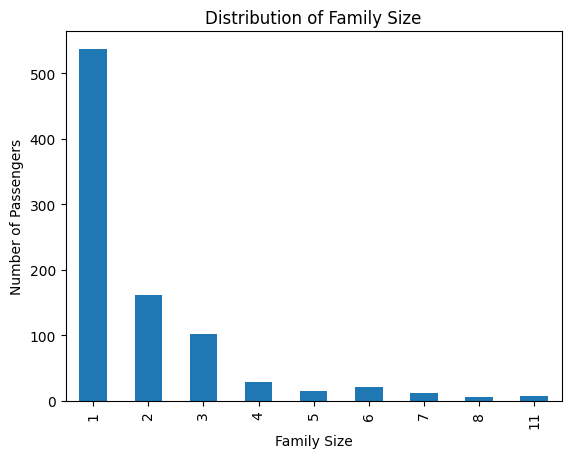


Survival Rate by FamilySize:
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


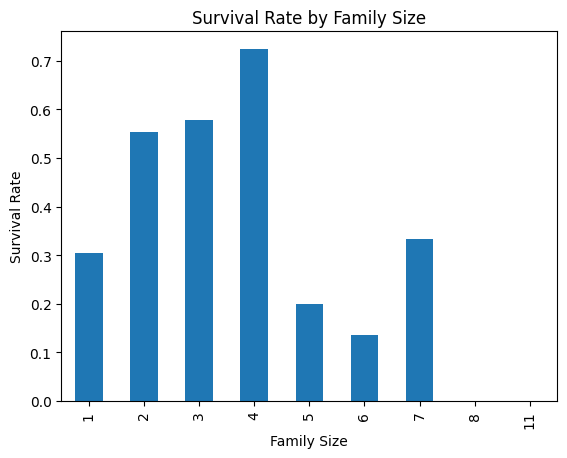


Pattern Interpretation:
Passengers traveling alone (FamilySize = 1) tend to have lower survival rates.
Small families (2–4 members) generally show higher survival rates.
Very large families tend to have lower survival rates.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Frequency Table for FamilySize
family_freq = df['FamilySize'].value_counts().sort_index()
print("Frequency Table for FamilySize:")
print(family_freq)

# Bar Chart for FamilySize Distribution
plt.figure()
family_freq.plot(kind='bar')
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")
plt.title("Distribution of Family Size")
plt.show()


#  Comparison of Survived vs FamilySize
survival_by_family = df.groupby('FamilySize')['Survived'].mean()

print("\nSurvival Rate by FamilySize:")
print(survival_by_family)

# Bar Chart for Survival Rate
plt.figure()
survival_by_family.plot(kind='bar')
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Family Size")
plt.show()


# Pattern Comments
print("\nPattern Interpretation:")
print("Passengers traveling alone (FamilySize = 1) tend to have lower survival rates.")
print("Small families (2–4 members) generally show higher survival rates.")
print("Very large families tend to have lower survival rates.")

In [ ]:
df['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Normalized (Min- max),Standardized (z-score),FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S,0.271174,-0.565736,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C,0.472229,0.663861,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S,0.321438,-0.258337,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S,0.434531,0.433312,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S,0.434531,0.433312,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,S,0.334004,-0.181487,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,S,0.233476,-0.796286,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,S,0.346569,-0.104637,4
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C,0.321438,-0.258337,1


In [ ]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Normalized (Min- max),Standardized (z-score),FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",NaN,22.0,1,0,A/5 21171,7.2500,S,0.271174,-0.565736,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",NaN,38.0,1,0,PC 17599,71.2833,C,0.472229,0.663861,2,0
2,3,1,3,"Heikkinen, Miss. Laina",NaN,26.0,0,0,STON/O2. 3101282,7.9250,S,0.321438,-0.258337,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",NaN,35.0,1,0,113803,53.1000,S,0.434531,0.433312,2,0
4,5,0,3,"Allen, Mr. William Henry",NaN,35.0,0,0,373450,8.0500,S,0.434531,0.433312,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",NaN,27.0,0,0,211536,13.0000,S,0.334004,-0.181487,1,1
887,888,1,1,"Graham, Miss. Margaret Edith",NaN,19.0,0,0,112053,30.0000,S,0.233476,-0.796286,1,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,28.0,1,2,W./C. 6607,23.4500,S,0.346569,-0.104637,4,0
889,890,1,1,"Behr, Mr. Karl Howell",NaN,26.0,0,0,111369,30.0000,C,0.321438,-0.258337,1,1
